## 10.06 自注意力和位置编码

### 环境配置

In [1]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
import os
import sys
sys.path.insert(0, "..")
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import torch
    from torch import nn

import matplotlib.pyplot as plt
from src.utils import plot, show_heatmaps

torch.manual_seed(0);


### 练习 10.6.1

**题目：** 假设设计一个深度架构，通过堆叠基于位置编码的自注意力层来表示序列。可能会存在什么问题？

**解答：** 堆叠多层"位置编码 + 自注意力"的纯自注意力架构（如早期无残差的 Transformer 原型）可能面临：

- **位置信息被"冲刷"**：位置编码在输入层一次性加入，经过多层自注意力后，位置信息可能被后续表示稀释，模型对远距离位置的区分能力下降；
- **无归纳偏置、优化困难**：自注意力没有 CNN 的局部性/平移等变性，也没有 RNN 的顺序先验，深层堆叠时梯度与表示的稳定性差，需要残差连接 + 层规范化 + 学习率调度才能稳定训练；
- **二次方复杂度**：每层自注意力复杂度 $\mathcal{O}(n^2)$，深网络叠加后长序列的计算与显存开销急剧增大；
- **固定位置编码的局限**：固定的正弦/余弦编码无法自适应不同数据集的最优频率分布，超长序列（超过 `max_len`）也需要外推处理。

缓解手段：残差连接 + AddNorm、多层堆叠时位置编码也可以逐层注入或采用可学习位置编码（见练习 10.6.2）。

### 练习 10.6.2

**题目：** 请设计一种可学习的位置编码方法。

**解答：** 把固定编码矩阵 $\mathbf{P}$ 改为**可学习参数**：随机初始化一个形状为 `(1, max_len, num_hiddens)` 的 `nn.Parameter`，随模型一起用反向传播训练。相比固定正弦/余弦编码，可学习编码能根据任务自适应调整各维度的频率与相位，但需要训练数据足够，否则容易过拟合位置模式。

下面演示可学习位置编码与固定编码的对比：

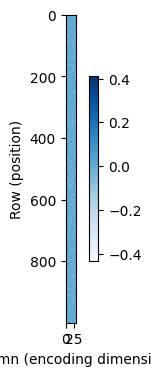

可学习位置编码参数量： 32000


In [2]:
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("torch_npu").setLevel(logging.WARNING)
class LearnablePositionalEncoding(nn.Module):
    """可学习的位置编码"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.P = nn.Parameter(torch.randn(1, max_len, num_hiddens) * 0.1)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :]
        return self.dropout(X)


# 固定（正弦/余弦）编码
class FixedPositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # 注册为 buffer：随模块 .to(device) 移动（与 src/attention.py 收录版一致）
        self.register_buffer('P', torch.zeros((1, max_len, num_hiddens)))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :]
        return self.dropout(X)


num_hiddens, num_steps = 32, 60
learnable = LearnablePositionalEncoding(num_hiddens, 0)
fixed = FixedPositionalEncoding(num_hiddens, 0)
X = torch.zeros((1, num_steps, num_hiddens))
# 初始随机编码的热图（训练后由反向传播更新）
P_learn = learnable.P.detach()[0, :, :].unsqueeze(0).unsqueeze(0)
show_heatmaps(P_learn, xlabel='Column (encoding dimension)',
              ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')
print('可学习位置编码参数量：', learnable.P.numel())

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)